# EDA - Data Visualisation


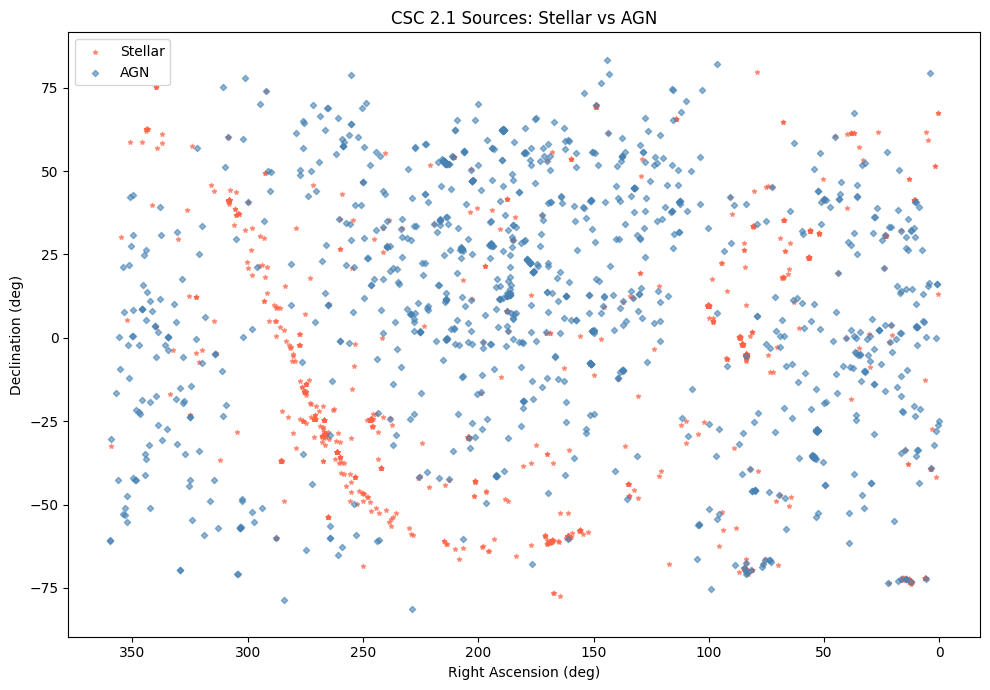

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/csc21_simbad_enriched.csv')

stellar = df[df['source_class'] == 'stellar']
agn = df[df['source_class'] == 'AGN']

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(stellar['ra'], stellar['dec'], s=10, alpha=0.6, color='tomato', label='Stellar', marker='*')
ax.scatter(agn['ra'], agn['dec'], s=10, alpha=0.6, color='steelblue', label='AGN', marker='D')

ax.set_xlabel('Right Ascension (deg)')
ax.set_ylabel('Declination (deg)')
ax.set_title('CSC 2.1 Sources: Stellar vs AGN')
ax.legend()
ax.invert_xaxis()  # RA increases to the left by convention

plt.tight_layout()
plt.savefig('scatter_stellar_agn.png', dpi=150)
plt.show()


From this plot it seems that AGN sources are more homogeneously distributed, while stellar sources follow a curve

In [ ]:
import pandas as pd

pd.set_option('display.float_format', '{:.4e}'.format)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)

df = pd.read_csv('data/csc21_simbad_enriched.csv')

cols = ['hard_hs', 'hard_hm', 'hard_ms', 'flux_aper_b', 'flux_aper_s', 'flux_aper_m', 'flux_aper_h']

df['source_class'] = df['source_class'].fillna('unmatched')

for cls in ['stellar', 'AGN', 'other', 'unmatched']:
    subset = df[df['source_class'] == cls]
    print(f'\n=== {cls} (n={len(subset)}) ===')
    print(subset[cols].describe().to_string())



=== stellar (n=1370) ===
          hard_hs     hard_hm     hard_ms  flux_aper_b  flux_aper_s  flux_aper_m  flux_aper_h
count  1.3700e+03  1.3600e+03  1.3610e+03   1.3590e+03   1.3480e+03   1.3470e+03   1.3560e+03
mean  -4.9554e-02  4.2616e-02 -1.2431e-01   1.3162e-12   1.7547e-13   9.9999e-14   1.0544e-12
std    6.9157e-01  4.9677e-01  5.1240e-01   1.2994e-11   1.5194e-12   5.4986e-13   1.2598e-11
min   -9.9938e-01 -9.9938e-01 -9.9938e-01   0.0000e+00   0.0000e+00   0.0000e+00   0.0000e+00
25%   -7.2798e-01 -3.3354e-01 -5.3716e-01   1.6511e-14   1.4157e-15   2.8705e-15   5.8071e-15
50%   -1.3991e-01 -2.1237e-02 -1.9738e-01   9.0642e-14   1.2891e-14   1.3870e-14   3.0726e-14
75%    6.4897e-01  3.9600e-01  2.2861e-01   3.2870e-13   7.4148e-14   5.5094e-14   1.4707e-13
max    9.9938e-01  9.9938e-01  9.9938e-01   3.4142e-10   5.2097e-11   1.5225e-11   3.4391e-10

=== AGN (n=1100) ===
          hard_hs     hard_hm     hard_ms  flux_aper_b  flux_aper_s  flux_aper_m  flux_aper_h
count  1.100

A few notable differences: AGN have significantly higher median fluxes across all bands (e.g. flux_aper_b median ~1.85e-12 vs ~2.31e-13 for stellar), and their hardness ratios are more tightly clustered with lower std, reflecting their more homogeneous spectral properties. Unmatched sources show the widest spread in hardness ratios and the lowest median fluxes, consistent with being generally fainter/noisier detections.

# Hypothesis Testing
We test for the hypothesis that AGN have harder spectra compared to stellar sources, based on their hardness ratios, specifically in the hard/medium and hard/soft band.

X-ray hardness ratios quantify spectral shape on [-1, +1]; higher values mean a harder spectrum. We test two ratios from CSC 2.1:

hard_hs: HR_HS = (H - S) / (H + S)

hard_hm: HR_HM = (H - M) / (H + M)

H0: AGN and stellar hardness distributions are identical.

H1 (one-sided): AGN are stochastically greater (harder).

The Mann–Whitney U test is non-parametric and rank-based. This is appropriate here since hardness ratios are bounded and non-normal.


hard_hs:  U = 795893.5,  p = 8.0516e-03,  rank-biserial r = -0.0563
hard_hm:  U = 890212.0,  p = 3.6956e-17,  rank-biserial r = -0.1956


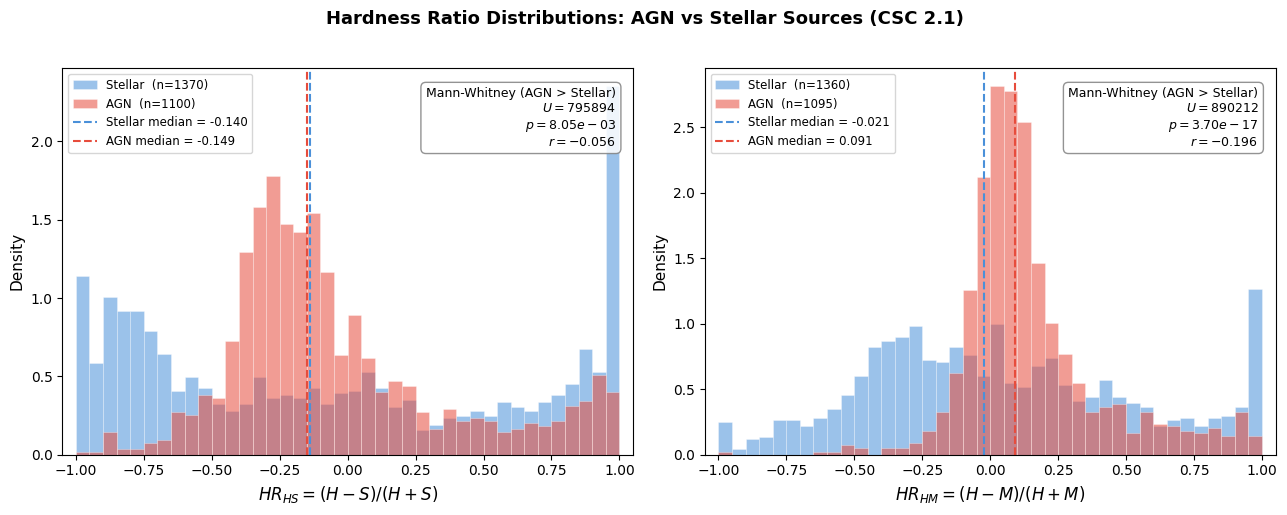

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ── Load & split ──────────────────────────────────────────────────────
df = pd.read_csv('data/csc21_simbad_enriched.csv')
agn     = df[df['source_class'] == 'AGN']
stellar = df[df['source_class'] == 'stellar']

# ── Mann-Whitney U tests ─────────────────────────────────────────────
results = {}
for col in ['hard_hs', 'hard_hm']:
    a = agn[col].dropna()
    s = stellar[col].dropna()
    U, p = mannwhitneyu(a, s, alternative='greater')
    r = 1 - 2 * U / (len(a) * len(s))
    results[col] = dict(U=U, p=p, r=r, n_agn=len(a), n_stel=len(s))
    print(f"{col}:  U = {U:.1f},  p = {p:.4e},  rank-biserial r = {r:.4f}")

# ── Histogram figure ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bins = np.linspace(-1, 1, 41)

titles = {
    'hard_hs': r'$HR_{HS} = (H-S)/(H+S)$',
    'hard_hm': r'$HR_{HM} = (H-M)/(H+M)$',
}

for ax, col in zip(axes, ['hard_hs', 'hard_hm']):
    a = agn[col].dropna()
    s = stellar[col].dropna()
    r = results[col]

    ax.hist(s, bins=bins, density=True, alpha=0.55, color='#4A90D9',
            label=f'Stellar  (n={r["n_stel"]})', edgecolor='white', linewidth=0.4)
    ax.hist(a, bins=bins, density=True, alpha=0.55, color='#E74C3C',
            label=f'AGN  (n={r["n_agn"]})', edgecolor='white', linewidth=0.4)

    # median lines
    ax.axvline(s.median(), color='#4A90D9', ls='--', lw=1.5, label=f'Stellar median = {s.median():.3f}')
    ax.axvline(a.median(), color='#E74C3C', ls='--', lw=1.5, label=f'AGN median = {a.median():.3f}')

    # annotation
    p_str = f"{r['p']:.2e}" if r['p'] > 1e-30 else f"{r['p']:.1e}"
    ax.text(0.97, 0.95,
            f"Mann-Whitney (AGN > Stellar)\n$U = {r['U']:.0f}$\n$p = {p_str}$\n$r = {r['r']:.3f}$",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85, ec='gray'))

    ax.set_xlabel(titles[col], fontsize=12)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=8.5, loc='upper left')
    ax.set_xlim(-1.05, 1.05)

fig.suptitle('Hardness Ratio Distributions: AGN vs Stellar Sources (CSC 2.1)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

For the H/M hardness ratio, we see that AGN have a clearly harder spectrum in the hard-medium band. Although the difference is much more small, we see that AGN have a slightly harder spectra in the hard-soft band as well.